### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib.pyplot as plt
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns


plt.rcParams['font.family'] = 'Helvetica'

DATA_PATH = './sims_out/1s_train_jax_summed_weight_2D_inh_het_0p2_test_426873_2D_1_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-10-24_13:36:34.624636_run_None'

In [2]:
def load_numpy(data_path, last_n=None):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    if last_n is not None:
        data = data[-last_n:]
    data = np.stack(data)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

### Analysis of weights

In [3]:
all_w = load_numpy(os.path.join(DATA_PATH, 'weights/net_005_*.npy'))

In [4]:
from matplotlib.colors import TwoSlopeNorm

def plot_step(run, v=6, save_name=None, mask=None, scale=3):
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True)

    # Use TwoSlopeNorm to ensure white maps to 0
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    
    # Plot the matrix
    if mask is None:
        im = axs.matshow(all_w[run, ...], cmap=cmap, norm=norm)
    else:
        print(all_w[run, ...][mask, :][:, mask])
        im = axs.matshow(all_w[run, ...][mask, :][:, mask], cmap=cmap, norm=norm)

    # Ticks and labels
    # axs.set_xticks([15, 30, 45])
    # axs.set_yticks([15, 30, 45])
    axs.tick_params(axis='both', labelsize=16)
    axs.set_xlabel('Presynaptic', fontsize=16)
    axs.set_ylabel('Postsynaptic', fontsize=16)
    axs.xaxis.set_label_position('top')
    axs.tick_params(axis='x', bottom=False)
    axs.tick_params(axis='both', length=10)
    axs.spines['right'].set_visible(False)
    axs.spines['bottom'].set_visible(False)

    # Add colorbar
    cbar = fig.colorbar(im, ax=axs, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label('Weight', fontsize=14)

    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

    return fig

In [ ]:
# Directory to save frames
frames_dir = "./weight_evo"
os.makedirs(frames_dir, exist_ok=True)

# Parameters
num_runs = 320
timestep = 0

# Generate and save plots as images
for run in range(num_runs):
    fig = plot_step(run)
    fig.tight_layout()
    frame_path = os.path.join(frames_dir, f"frame_{run:03}_{timestep:04}.png")
    fig.tight_layout()
    fig.savefig(frame_path)
    plt.close(fig)  # Free memory

In [ ]:
# Parameters
image_folder = './weight_evo'     # directory with images
output_video = 'output.mp4'       # output filename
fps = 30                          # frames per second

# Get all .png files, sorted naturally
images = [img for img in os.listdir(image_folder) if img.endswith(".png")]
images = natsorted(images)  # natural sort: img1, img2, ..., img10

# Read first image to get dimensions
first_frame = cv2.imread(os.path.join(image_folder, images[0]))
height, width, layers = first_frame.shape

# Define the video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or 'XVID' for .avi
video = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# Add frames
for image in images:
    frame = cv2.imread(os.path.join(image_folder, image))
    video.write(frame)

video.release()
print("Video written to", output_video)

[[ 0.12668446  0.10229331 -3.53479555]
 [ 0.13073047  0.31281833 -2.99079957]
 [ 1.25        1.25        0.        ]]


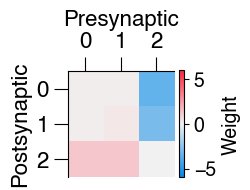

In [5]:
# plot run 0, timestep 0
mask = np.array([1, 1, 0, 0, 0, 0, 1]).astype(bool)
f = plot_step(0, save_name='./figures/initial_weight_mat.svg', mask=mask, scale=1.5)

[[ 3.90339589  4.85228014 -3.53479552]
 [ 3.16600347  3.6080904  -2.99079967]
 [ 1.25        1.25        0.        ]]


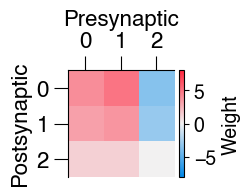

In [6]:
mask = np.array([1, 1, 0, 0, 0, 0, 1]).astype(bool)
f = plot_step(320, save_name='./figures/initial_weight_mat.svg', mask=mask, v=8, scale=1.5)
None

[[ 3.45748997  4.77907896 -3.53479552]
 [ 3.15015507  3.98023677 -2.99079967]
 [ 1.25        1.25        0.        ]]


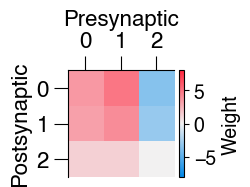

In [7]:
mask = np.array([1, 1, 0, 0, 0, 0, 1]).astype(bool)
f = plot_step(410, save_name='./figures/initial_weight_mat.svg', mask=mask, v=8, scale=1.5)
None

[<Axes: ylabel='$w_{11} - w_{21}$'> <Axes: ylabel='$w_{22} - w_{12}$'>]
[<Axes: ylabel='Diagonal terms'>
 <Axes: xlabel='Epoch', ylabel='Off-diagonal terms'>]
Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


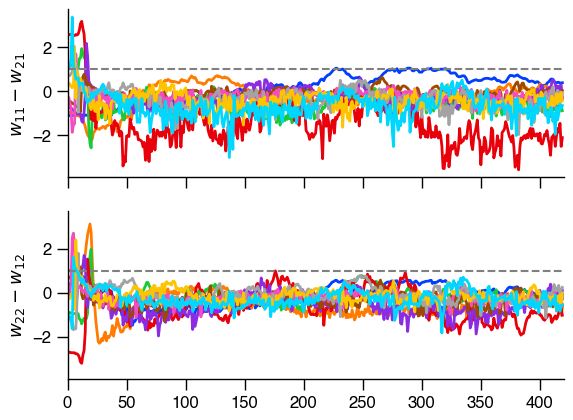

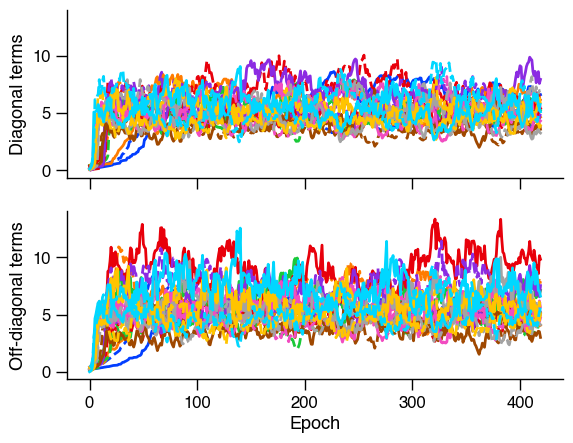

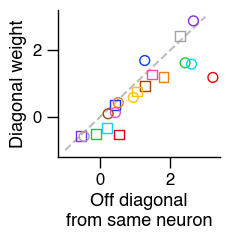

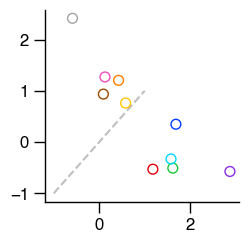

In [8]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)
fig_w, axs_w = plt.subplots(2, 1, sharex=True, sharey=True)
fig_2, axs_2 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(2.5, 2.5))
fig_3, axs_3 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(2.5, 2.5))

# Create a colormap with 10 distinct colors
colors = sns.color_palette('bright', 10)

for i in range(10):
    all_w = load_numpy(os.path.join(DATA_PATH, f'weights/net_00{i}_*.npy'))
    
    # Use a different color for each iteration
    color = colors[i]

    w11 = all_w[:, 0, 0]
    w12 = all_w[:, 0, 1]
    w22 = all_w[:, 1, 1]
    w21 = all_w[:, 1, 0]

    w_inh_1 = all_w[:, 0, -1]
    w_inh_2 = all_w[:, 1, -1]

    w11_adj = w11 + w_inh_1
    w12_adj = w12 + w_inh_1
    w22_adj = w22 + w_inh_2
    w21_adj = w21 + w_inh_2

    axs[0].plot(np.arange(all_w.shape[0]), w11_adj - w21_adj, color=color, lw=2)
    axs[1].plot(np.arange(all_w.shape[0]), w22_adj - w12_adj, color=color, lw=2)

    axs_w[0].plot(np.arange(all_w.shape[0]), w11, color=color, lw=2)
    axs_w[0].plot(np.arange(all_w.shape[0]), w22, color=color, lw=2, ls='--')
    axs_w[1].plot(np.arange(all_w.shape[0]), w21, color=color, lw=2)
    axs_w[1].plot(np.arange(all_w.shape[0]), w12, color=color, lw=2, ls='--')

    axs_2.scatter(w21_adj[-10:].mean(), w11_adj[-10:].mean(), edgecolor=color, facecolor='none', s=50)
    axs_2.scatter(w12_adj[-10:].mean(), w22_adj[-10:].mean(), edgecolor=color, facecolor='none', s=50, marker='s')

    axs_3.scatter(w11_adj[-10:].mean(), w22_adj[-10:].mean(), edgecolor=color, facecolor='none', s=50)

axs[0].axhline(1, color='grey', ls='--')
# axs[0].set_ylim(-1, 2)
axs[0].set_xlim(0, all_w.shape[0])
axs[0].set_ylabel(r'$w_{11} - w_{21}$')

axs[1].axhline(1, color='grey', ls='--')
# axs[1].set_ylim(-1, 2)
axs[1].set_xlim(0, all_w.shape[0])
axs[1].set_ylabel(r'$w_{22} - w_{12}$')

axs_w[1].set_xlabel('Epoch')
axs_w[0].set_ylabel('Diagonal terms')
axs_w[1].set_ylabel('Off-diagonal terms')

axs_2.set_ylabel('Diagonal weight')
axs_2.set_xlabel('Off diagonal\nfrom same neuron')

# axs_2[1].set_xlabel(r'$w_{21}$')
# axs_2[1].set_ylabel(r'$w_{22}$')

# axs_2.set_xlim(-4, 0)
# axs_2.set_ylim(-2, 2)

axs_2.plot([-1, 3], [-1, 3], zorder=-1, ls='--', color='gray', alpha=0.5)

# axs_3.set_xlim(0, 1)
# axs_3.set_ylim(0, 1)

axs_3.plot([-1, 1], [-1, 1], zorder=-1, ls='--', color='gray', alpha=0.5)

format_plot(axs)
format_plot(axs_w)
format_plot(axs_2)
format_plot(axs_3)

fig_2.tight_layout()

In [3]:
def plot_weight_changes(data_paths):
    fig, axs = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(4.5, 1.5))
    
    # Create a colormap with 10 distinct colors
    colors = sns.color_palette('bright', 3)

    for j, dp in enumerate(data_paths):
        # Use a different color for each iteration
        color = colors[j]
        w_changes_over_epochs = []
        for i in range(10):
            all_w = load_numpy(os.path.join(dp, f'weights/net_00{i}_*.npy'))
        
            w11 = all_w[:, 0, 0]
            w12 = all_w[:, 0, 1]
            w22 = all_w[:, 1, 1]
            w21 = all_w[:, 1, 0]
        
            w_inh_1 = all_w[:, 0, -1]
            w_inh_2 = all_w[:, 1, -1]
        
            w11_adj = w11 + w_inh_1
            w12_adj = w12 + w_inh_1
            w22_adj = w22 + w_inh_2
            w21_adj = w21 + w_inh_2
        
            w_changes_over_epochs.append(np.array([
                np.linalg.norm(all_w[i+1, :2, :2] - all_w[i, :2, :2]) for i in range(all_w.shape[0] - 1)
            ]))
        
        w_changes_over_epochs = np.stack(w_changes_over_epochs)
        
        axs.plot(np.arange(w_changes_over_epochs.shape[1]), w_changes_over_epochs.mean(axis=0), color=color)

    axs.set_xlabel('Epochs')
    axs.set_ylabel(r'$||\Delta W||$')
    axs.set_yscale('log')
    format_plot(axs)

    fig.tight_layout()
    fig.savefig('./figures/weight_changes.svg')

Axes(0.125,0.11;0.775x0.77)


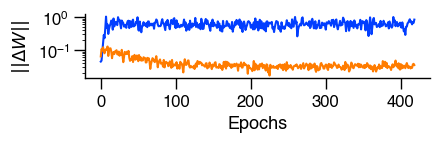

In [54]:
plot_weight_changes([
    './sims_out/1s_train_jax_no_noise_2D_inh_het_0p2_test_252803_2D_1_TH_0_STD_EXPL_0.0002__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-10-04_10:12:02.684663_run_None',
    './sims_out/260ms_jax_no_noise_2D_test_842587_2D_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-10-06_16:46:43.748457_run_None',
])

### Analysis of neural activity

In [4]:
all_r = load_numpy(os.path.join(DATA_PATH, 'activities/net_005_*.npy'), last_n=100)

In [5]:
# shape of activity matrix is 320 trials, 1000 time steps, 46 units
all_r.shape

(100, 10000, 7)

In [6]:
last_100_r = all_r[-100:, :, :2] # keep only last 50 trials, when plasticity has organized functional circuit
# also keep only 15 units in 'ellipsoid body'

Do PCA on last 50 trials, 15 units in ellipsoid body.

In [7]:
last_100_r = np.transpose(last_100_r, [2, 0, 1])

flattened_data = last_100_r.reshape(last_100_r.shape[0], last_100_r.shape[1] * last_100_r.shape[2], order='C')

pca = PCA()
pc_activities = pca.fit_transform(flattened_data.T)
pc_activities = pc_activities.T.reshape(last_100_r.shape, order='C')

In [8]:
pc_activities.shape

(2, 100, 10000)

Learned structure leads to low dimensional activity.

Axes(0.125,0.11;0.775x0.77)


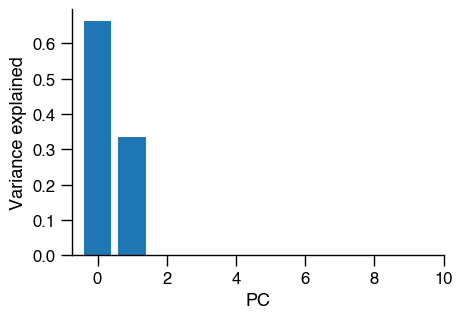

In [9]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

explained_variance_ratios = pca.explained_variance_ratio_
axs.bar(np.arange(explained_variance_ratios.shape[0]), explained_variance_ratios)
axs.set_xlim(-0.75, 10)
axs.set_ylabel('Variance explained')
axs.set_xlabel('PC')
format_plot(axs)

Retrieve target integrated sums. Keep only the last 100 trials.

In [10]:
all_int_values_raw = load_numpy(os.path.join(DATA_PATH, 'integrated_values/net_005_*.npy'), last_n=100)
all_int_values = all_int_values_raw[-100:, :]

In [11]:
print(all_int_values.shape)

(100, 9800)


Plot last 800 timesteps, when input is active, and color by correct integrated sum.

Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.62x0.77)


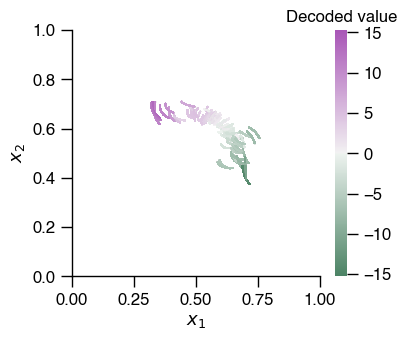

In [12]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(5 * scale, 4 * scale))

max_abs_int_val = np.abs(all_int_values).max()


for i in range(0, 100, 1):
    if all_int_values.shape[-1] < last_100_r.shape[-1]:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], last_100_r.shape[-1] - all_int_values.shape[-1])),
        ], axis=1)

        
    
    cbar = axs.scatter(
        last_100_r[0, i, 10 * (20 + 500):],
        last_100_r[1, i, 10 * (20 + 500):],
        cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True),
        s=0.01,
        c=all_int_values[i, (10 * 500):-200],
        vmin=-max_abs_int_val,
        vmax=max_abs_int_val,
    )
    if i == 0:
        cbar_ax = plt.colorbar(cbar)
        format_plot(cbar_ax.ax, leftspine=False, bottomspine=False)
        cbar_ax.ax.set_title('Decoded value')
axs.set_xlabel(r'$x_1$')
axs.set_ylabel(r'$x_2$')
axs.set_xlim(0, 1)
axs.set_ylim(0, 1)

format_plot(axs)

cbar_ax.outline.set_visible(False)

# axs.set_xlim(-1.25, 1.25)
# axs.set_ylim(-1.25, 1.25)

Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.62x0.77)


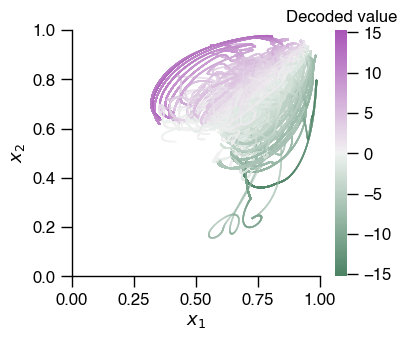

In [13]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(5 * scale, 4 * scale))

max_abs_int_val = np.abs(all_int_values).max()


for i in range(0, 100, 1):
    if all_int_values.shape[-1] < last_100_r.shape[-1]:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], last_100_r.shape[-1] - all_int_values.shape[-1])),
        ], axis=1)

        
    
    cbar = axs.scatter(
        last_100_r[0, i, 10 * 20:],
        last_100_r[1, i, 10 * 20:],
        cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True),
        s=0.01,
        c=all_int_values[i, :-200],
        vmin=-max_abs_int_val,
        vmax=max_abs_int_val,
    )
    if i == 0:
        cbar_ax = plt.colorbar(cbar)
        format_plot(cbar_ax.ax, leftspine=False, bottomspine=False)
        cbar_ax.ax.set_title('Decoded value')
axs.set_xlabel('Unit 1')
axs.set_ylabel('Unit 2')
axs.set_xlabel(r'$x_1$')
axs.set_ylabel(r'$x_2$')
axs.set_xlim(0, 1)
axs.set_ylim(0, 1)

format_plot(axs)

cbar_ax.outline.set_visible(False)

# axs.set_xlim(-1.25, 1.25)
# axs.set_ylim(-1.25, 1.25)

/tmp/ipykernel_2687463/458187651.py:11: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


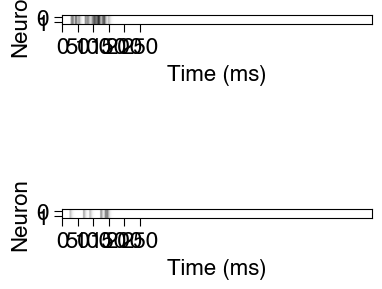

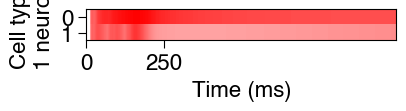

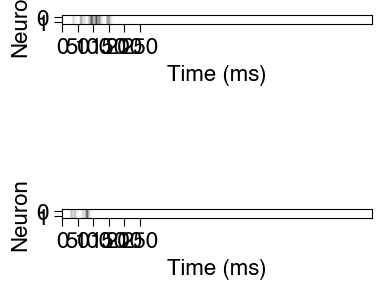

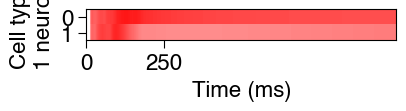

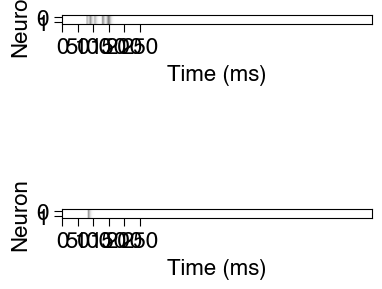

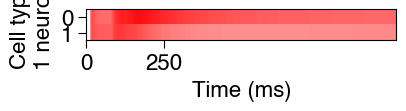

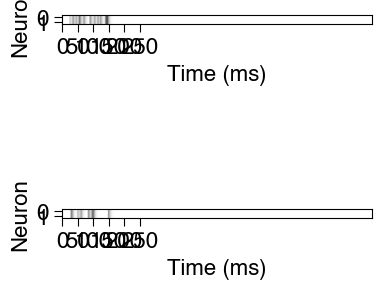

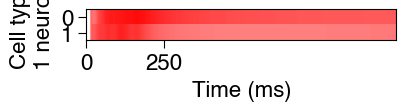

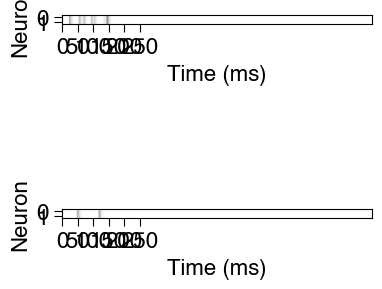

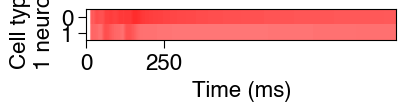

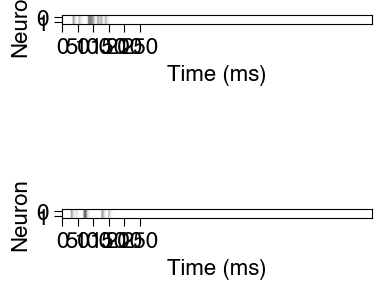

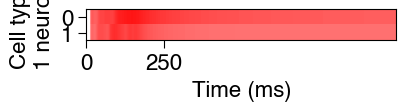

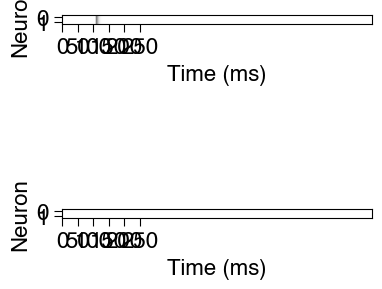

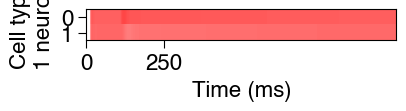

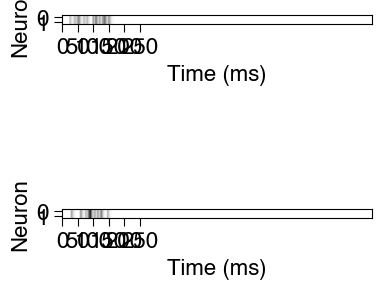

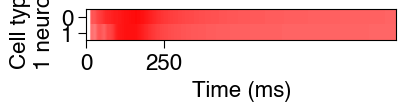

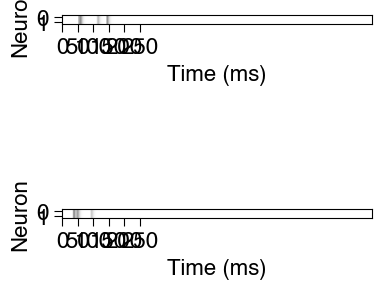

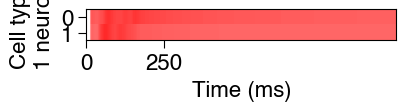

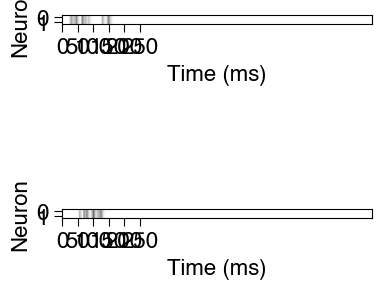

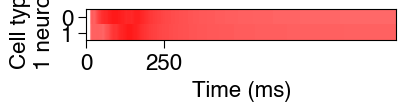

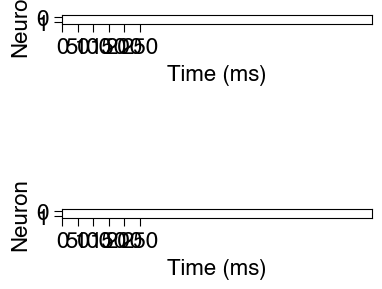

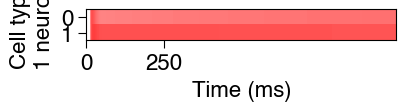

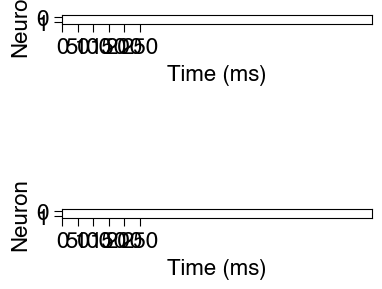

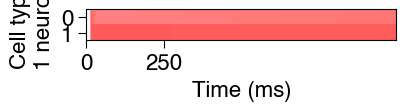

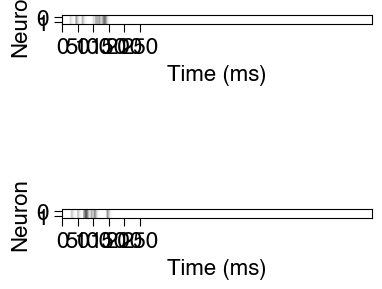

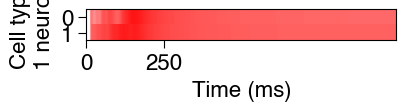

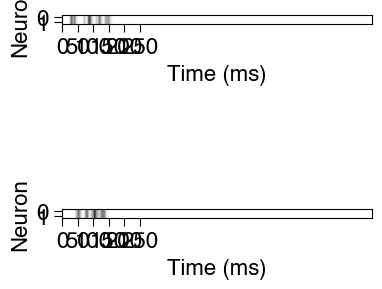

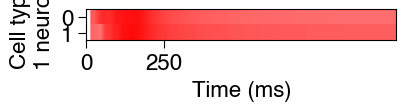

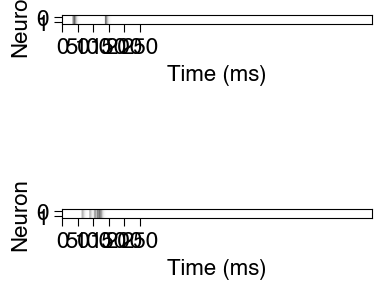

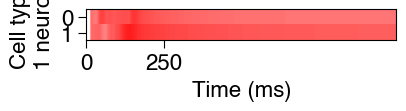

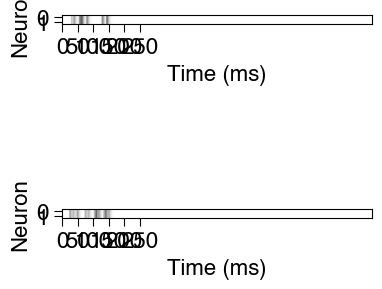

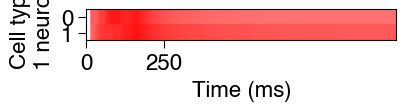

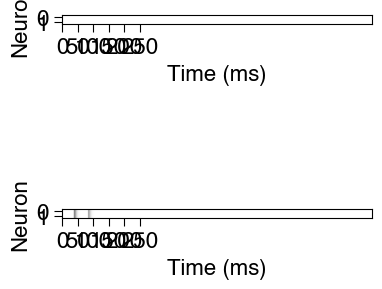

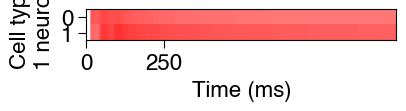

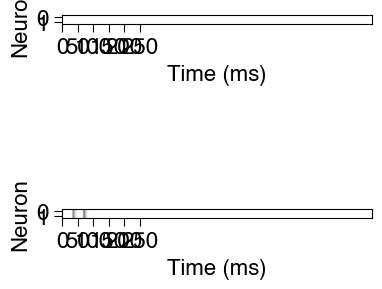

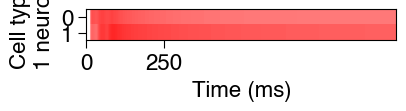

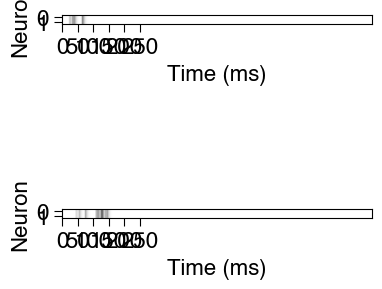

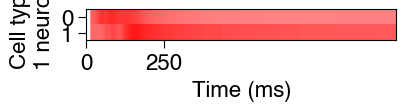

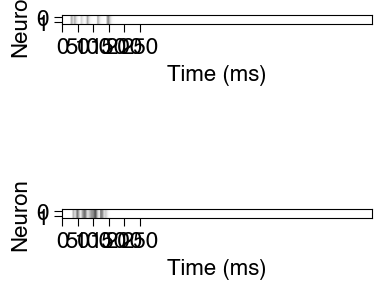

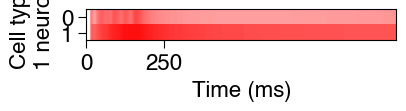

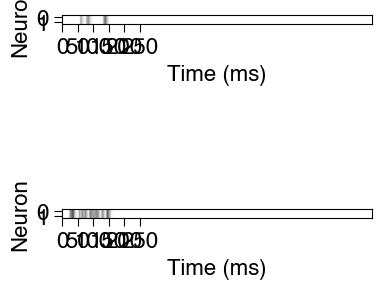

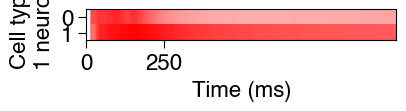

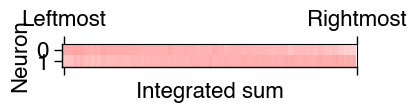

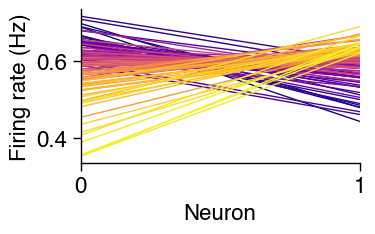

In [16]:
scale = 4

inputs_raw = load_numpy(os.path.join(DATA_PATH, 'inputs/net_005_*.npy'))
inputs = np.concatenate([np.zeros((100, 200, 4)), inputs_raw[-100:, ...]], axis=1)

ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))

for i, j in enumerate(np.argsort(all_int_values[:, -1])):
    
    if i % 5 == 0 or i == len(all_int_values[:, -1]) - 1:
        fig, axs = plt.subplots(2, 1, figsize=(1 * scale, 1 * scale))
        axs[0].matshow(inputs[j, :, :2].T, cmap='binary', vmin=0, vmax=30, aspect=150)
        axs[1].matshow(inputs[j, :, 2:].T, cmap='binary', vmin=0, vmax=30, aspect=150)
        for k in range(2):
            axs[k].set_xlabel('Time (ms)', fontsize=16)
            if k == 0:
                axs[k].set_ylabel('Neuron', fontsize=16)
            else:
                axs[k].set_ylabel('Neuron', fontsize=16)
            axs[k].set_xticks(np.arange(0, 2501, 500), (np.arange(0, 2501, 500) / 10).astype(int))
            # axs[k].set_yticks([0, 15])
            axs[k].tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
            axs[k].xaxis.set_label_position('bottom')
            axs[k].tick_params(axis='both', length=6, labelsize=16)
        plt.subplots_adjust(top=1)

        fig.savefig(f'./figures/inputs_{i}.svg', bbox_inches='tight')


        fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
        axs.matshow(last_100_r[:, j, :], cmap='bwr', vmin=-1, vmax=1, aspect=500)
        axs.set_xlabel('Time (ms)', fontsize=16)
        axs.set_ylabel('Cell type\n1 neuron', fontsize=16)
        axs.set_xticks(np.arange(0, 2501, 2500), (np.arange(0, 2501, 2500) / 10).astype(int))
        # axs.set_yticks([0, 15])
        axs.tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)
        axs.xaxis.set_label_position('bottom')
        axs.tick_params(axis='both', length=6, labelsize=16)
        fig.savefig(f'./figures/single_pool_activity_trace_{i}.svg', bbox_inches='tight')
    
for i, j in enumerate(np.argsort(all_int_values[:, -250])):
    ending_states[:, i] = last_100_r[:, j, -250]
    
#     fig.savefig(os.path.join(img_path, f'act_{zero_pad(run, 4)}_t_{zero_pad(timestep, 4)}.png'))
#     plt.close()

scale = 3.5
fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
axs.matshow(ending_states, cmap='bwr', vmin=-2, vmax=2, aspect=4)

format_plot(axs, rightspine=True, topspine=True)
fig.tight_layout()

axs.set_xlabel('Integrated sum', fontsize=16)
axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
axs.set_ylabel('Neuron', fontsize=16)
axs.set_yticks([0, 1])
axs.tick_params(axis='both', length=6, labelsize=16)

scale = 2
fig, axs = plt.subplots(1, 1, figsize=(1.8 * scale, 1 * scale))

import matplotlib.pyplot as plt
import numpy as np

plasma = plt.get_cmap("plasma")
colors = [plasma(i / 100)[:3] for i in range(100)]  # 49 to include 0 and 1

for i in range(ending_states.shape[1]):
    axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

format_plot(axs)

axs.set_ylabel('Firing rate (Hz)', fontsize=16)
axs.set_xlabel('Neuron', fontsize=16)
axs.set_xticks([0, 1])
axs.set_xlim(0, 1)
axs.tick_params(axis='both', length=6, labelsize=16)
    

### Testing usefulness of representation
Grab trials 280-300 and 300-320. Train linear decode on the first set at random points in time. Test on set of activations from the second set.

In [22]:
all_r = load_numpy(os.path.join(DATA_PATH, 'activities/net_005_*.npy'), last_n=420)
all_int_values_raw = load_numpy(os.path.join(DATA_PATH, 'integrated_values/net_005_*.npy'), last_n=420)

train_range = slice(280, 320)
test_range = slice(320, 420)
readout_neuron_range = slice(0, 2)

stacked_activities_train = all_r[train_range, 200:, readout_neuron_range]
y_train = all_int_values_raw[train_range, :]
stacked_activities_test = all_r[test_range, 200:, readout_neuron_range]
y_test = all_int_values_raw[test_range, :]

scores = []

for i in range(100):
    train_acts = np.random.randint(0, 20, size=1000)
    train_steps = np.random.randint(0, stacked_activities_train.shape[1], size=1000)
    test_acts = np.arange(100)
    test_steps = np.random.randint(0, stacked_activities_test.shape[1], size=100)
    
    X_train = stacked_activities_train[train_acts, train_steps, :]
    Y_train = y_train[train_acts, train_steps]
    
    X_test = stacked_activities_test[test_acts, test_steps, :]
    Y_test = y_test[test_acts, test_steps]
    
    reg = LinearRegression().fit(X_train, Y_train)
    score = reg.score(X_test, Y_test)
    scores.append(score)

print(scores)
print(np.mean(scores))

[0.8680227007433898, 0.8545175381644621, 0.8503776466351498, 0.8346592922184848, 0.8376890528305819, 0.8073513401421831, 0.8062312241554577, 0.879280827330672, 0.8373932277766641, 0.860882429860974, 0.8393292033946983, 0.8666344377874408, 0.7805806469040641, 0.8813099378572874, 0.8221843634867869, 0.8379416173243794, 0.885386208060793, 0.8122591635733828, 0.8524169717728243, 0.8194241331333231, 0.87432686025073, 0.8613821520218868, 0.8533419480674476, 0.8343067833909688, 0.8680641085826003, 0.8705275102590797, 0.8387021901974401, 0.8121297601229941, 0.8407383362765177, 0.8212419542444642, 0.8645036165912181, 0.8440150214481115, 0.8306796866991495, 0.8698438149677761, 0.8561378796905796, 0.8934347310883735, 0.8404737538260569, 0.8800328470699944, 0.8189618123643789, 0.8507815092312783, 0.844137532413288, 0.8243865953870613, 0.822037878019307, 0.8618627695406431, 0.8622428358268297, 0.8500378327155638, 0.8024101967092876, 0.8657788718564114, 0.8463478973764802, 0.8728249757136068, 0.8516

Axes(0.125,0.11;0.775x0.77)


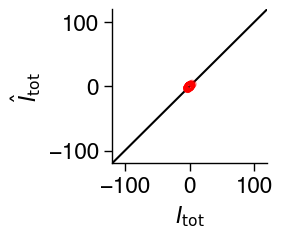

In [47]:
scale = 0.5
fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

axs.plot([-120, 120], [-120, 120], color='black', zorder=0)
axs.scatter(Y_test, reg.predict(X_test), s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
axs.set_xlim(-120, 120)
axs.set_ylim(-120, 120)
axs.set_xticks([-100, 0, 100])
axs.set_yticks([-100, 0, 100])

format_plot(axs)

axs.set_xlabel(r'$I_{\rm tot}$', fontsize=16)
axs.set_ylabel(r'$\hat{I}_{\rm tot}$', fontsize=16)
# axs.set_title('Predicted vs true integrated sums', fontsize=16)
axs.tick_params(axis='both', length=6, labelsize=16)
fig.savefig('./figures/predicted_vs_true.svg', bbox_inches='tight')

In [ ]:
train_range = slice(280, 300)
test_range = slice(300, 400)
readout_neuron_range = slice(0, 15)

stacked_activities_train = all_r[train_range, 200:, readout_neuron_range]
y_train = all_int_values_raw[train_range, :]
stacked_activities_test = all_r[test_range, 200:, readout_neuron_range]
y_test = all_int_values_raw[test_range, :]

scores = []

train_acts = np.random.randint(0, 20, size=1000)
train_steps = np.random.randint(0, 800, size=1000)
test_acts = np.arange(100)
test_steps = np.random.randint(0, 800, size=100)

X_train = stacked_activities_train[train_acts, train_steps, :]
Y_train = y_train[train_acts, train_steps]

X_test = stacked_activities_test[test_acts, test_steps, :]
Y_test = y_test[test_acts, test_steps]

reg = LinearRegression().fit(X_train, Y_train)
score = reg.score(X_test, Y_test)
scores.append(score)

print(scores)
print(np.mean(scores))

In [ ]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

axs.plot([-120, 120], [-120, 120], color='black', zorder=0)
axs.scatter(Y_test, reg.predict(X_test), s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
axs.set_xlim(-120, 120)
axs.set_ylim(-120, 120)
axs.set_xlabel(r'$y$', fontsize=16)
axs.set_ylabel(r'$\hat{y}$', fontsize=16)
axs.set_title('Predicted vs true integrated sums', fontsize=16)
axs.tick_params(axis='both', length=6, labelsize=16)